In [1]:
import pandas as pd
import os


In [2]:
vllm_reports_list = [k for k in os.listdir() if k.endswith(".xlsx") and "full_finetune" not in k and "clear" in k]
vllm_reports_list

['VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx',
 'VLLM_TEST_with_metrics_clear_model_ruslandev_llama-3-8b-gpt-4o-ru1.0.xlsx',
 'VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx']

In [3]:
df = pd.read_excel(vllm_reports_list[0])
df["Adapter_name"] = vllm_reports_list[0]
df

,Promts,References,Answers,Response times,Completion tokens,Tokens per second,Exact Match,BLEU,ROUGE-L,METEOR,BERTScore F1,Adapter_name
0,"Мой кариотип 46,XX,t(9;13)(p11;q21). Что это з...",Тип перестройки: сбалансированная реципрокная ...,"Ваш кариотип 46,XX,t(9;13)(p11;q21) — это кари...",5.767717,544,94.318075,0,0.008958,0.256410,0.069444,0.685602,VLLM_TEST_with_metrics_clear_model_meta-llama_...
1,"Мой кариотип 46,XX,inv(17)(q32q33). Что это зн...","Кариотип: 46,XX,inv(17)(q32q33)\nТип хромосомн...","Вариация 46,XX,inv(17)(q32q33) — это кариотип,...",3.441662,331,96.174472,0,0.002929,0.372881,0.083920,0.674410,VLLM_TEST_with_metrics_clear_model_meta-llama_...
2,"Мой кариотип 47,XX,+8[10]/46,XX[15]. Что это з...","Кариотип: 47,XX,+8[10]/46,XX[15]\nТип хромосом...","В кариотипе человека 23 пары хромосом, что в с...",1.971795,189,95.851772,0,0.001212,0.588235,0.036691,0.660827,VLLM_TEST_with_metrics_clear_model_meta-llama_...
3,"Мой кариотип 49,XXXXY. Что это значит?","Кариотип: 49,XXXXY\nТип хромосомной аномалии: ...","Кариотип 49,XXXXY — это генетическое нарушение...",4.170541,401,96.150599,0,0.001648,0.476190,0.063063,0.624627,VLLM_TEST_with_metrics_clear_model_meta-llama_...
4,"Мой кариотип 45,XY,der(22;22)(q10;q10). Что эт...","Кариотип: 45,XY,der(22;22)(q10;q10)\nТип перес...","В кариотипе человека 23 пары хромосом, что в с...",1.298194,124,95.517289,0,0.000017,0.097561,0.020548,0.662267,VLLM_TEST_with_metrics_clear_model_meta-llama_...
...,...,...,...,...,...,...,...,...,...,...,...,...
100,"Мой кариотип 45,XY,der(21;22)(q10;q10). Что эт...",Тип перестройки: сбалансированная Робертсоновс...,"В кариотипе человека 23 пары хромосом, что в с...",0.943619,90,95.377440,0,0.000125,0.115385,0.019125,0.645206,VLLM_TEST_with_metrics_clear_model_meta-llama_...
101,"Мой кариотип 47,XX,+i(12)(p10). Что это значит?","Кариотип: 47,XX,+i(12)(p10)\nТип: изохромосома...",В кариотипе человека 46 хромосом. В вашем случ...,1.140116,109,95.604348,0,0.004123,0.363636,0.026178,0.656143,VLLM_TEST_with_metrics_clear_model_meta-llama_...
102,"Мой кариотип 46,XX,del(8)(p22). Что это значит?","Кариотип: 46,XX,del(8)(p22)\nТип хромосомной а...","Ваш кариотип 46,XX,del(8)(p22) — это кариотипи...",5.476956,525,95.856172,0,0.003251,0.277778,0.088722,0.643163,VLLM_TEST_with_metrics_clear_model_meta-llama_...
103,"Мой кариотип 46,XX,del(3)(q29q29). Что это зна...","Кариотип: 46,XX,del(3)(q29q29)\nТип хромосомно...","Ваш кариотип 46,XX,del(3)(q29q29) — это кариот...",5.145403,493,95.813683,0,0.002888,0.292683,0.067144,0.647040,VLLM_TEST_with_metrics_clear_model_meta-llama_...


In [4]:
dfs_list = []
for i in range(len(vllm_reports_list)):
    df = pd.read_excel(vllm_reports_list[i])
    df["Adapter_name"] = vllm_reports_list[i]
    dfs_list.append(df)
dfs_all = pd.concat(dfs_list, ignore_index = True)
dfs_all.shape

(315, 12)

In [5]:
print("Всего записей:", dfs_all.shape[0])
print("Уникальных адаптеров:", dfs_all['Adapter_name'].nunique())
print("Количество тестов на адаптер:\n", dfs_all['Adapter_name'].value_counts().head())

Всего записей: 315
Уникальных адаптеров: 3
Количество тестов на адаптер:
 Adapter_name
VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx     105
VLLM_TEST_with_metrics_clear_model_ruslandev_llama-3-8b-gpt-4o-ru1.0.xlsx    105
VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx           105
Name: count, dtype: int64


In [6]:
# Ячейка 2
quality = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1']
performance = ['Response times', 'Completion tokens', 'Tokens per second']

print("=== ОБЩАЯ СТАТИСТИКА ===")
print(dfs_all[quality+performance].describe())

print("\n=== ПЕРЦЕНТИЛИ ДЛЯ КАЧЕСТВА ===")
for p in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"\n{p*100:5.0f}%:")
    for m in quality:
        val = dfs_all[m].quantile(p)
        print(f"   {m:12s} : {val:.4f}")

=== ОБЩАЯ СТАТИСТИКА ===
       Exact Match        BLEU     ROUGE-L      METEOR  BERTScore F1  \
count        315.0  315.000000  315.000000  315.000000    315.000000   
mean           0.0    0.002635    0.307124    0.041560      0.629947   
std            0.0    0.004087    0.162887    0.032844      0.058459   
min            0.0    0.000000    0.023256    0.000000      0.474419   
25%            0.0    0.000002    0.169492    0.005767      0.602812   
50%            0.0    0.001066    0.303030    0.040186      0.648832   
75%            0.0    0.003627    0.415584    0.069192      0.670666   
max            0.0    0.029708    0.800000    0.141760      0.750418   

       Response times  Completion tokens  Tokens per second  
count      315.000000         315.000000         315.000000  
mean         5.216803         499.803175          95.326758  
std          5.665523         543.479647           2.477113  
min          0.170552          16.000000          53.402939  
25%          1.1

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [8]:
# Данные уже загружены в dfs_all (из предыдущих ячеек)
# Проверим размер и состав
print("Размер данных:", dfs_all.shape)
print("\nПервые 2 строки:")
dfs_all.head(2)

Размер данных: (315, 12)

Первые 2 строки:


,Promts,References,Answers,Response times,Completion tokens,Tokens per second,Exact Match,BLEU,ROUGE-L,METEOR,BERTScore F1,Adapter_name
0,"Мой кариотип 46,XX,t(9;13)(p11;q21). Что это з...",Тип перестройки: сбалансированная реципрокная ...,"Ваш кариотип 46,XX,t(9;13)(p11;q21) — это кари...",5.767717,544,94.318075,0,0.008958,0.256410,0.069444,0.685602,VLLM_TEST_with_metrics_clear_model_meta-llama_...
1,"Мой кариотип 46,XX,inv(17)(q32q33). Что это зн...","Кариотип: 46,XX,inv(17)(q32q33)\nТип хромосомн...","Вариация 46,XX,inv(17)(q32q33) — это кариотип,...",3.441662,331,96.174472,0,0.002929,0.372881,0.083920,0.674410,VLLM_TEST_with_metrics_clear_model_meta-llama_...


In [9]:
# Убедимся, что нет пропусков в ключевых метриках
print("Пропуски:\n", dfs_all[['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1', 
                              'Response times', 'Tokens per second']].isnull().sum())

Пропуски:
 Exact Match          0
BLEU                 0
ROUGE-L              0
METEOR               0
BERTScore F1         0
Response times       0
Tokens per second    0
dtype: int64


In [10]:
# Основные статистики для всех метрик
metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1', 
           'Response times', 'Completion tokens', 'Tokens per second']
desc_all = dfs_all[metrics].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
desc_all

,Exact Match,BLEU,ROUGE-L,METEOR,BERTScore F1,Response times,Completion tokens,Tokens per second
count,315.0,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,0.0,0.002635,0.307124,0.041560,0.629947,5.216803,499.803175,95.326758
std,0.0,0.004087,0.162887,0.032844,0.058459,5.665523,543.479647,2.477113
min,0.0,0.000000,0.023256,0.000000,0.474419,0.170552,16.000000,53.402939
1%,0.0,0.000000,0.027855,0.000000,0.489819,0.189916,18.000000,92.445572
5%,0.0,0.000000,0.058203,0.000000,0.504809,0.243620,23.000000,93.858103
10%,0.0,0.000000,0.101869,0.002325,0.535214,0.266225,25.000000,94.272651
25%,0.0,0.000002,0.169492,0.005767,0.602812,1.176450,112.500000,95.415320
50%,0.0,0.001066,0.303030,0.040186,0.648832,3.720567,356.000000,95.737699
75%,0.0,0.003627,0.415584,0.069192,0.670666,5.357145,513.500000,95.863618


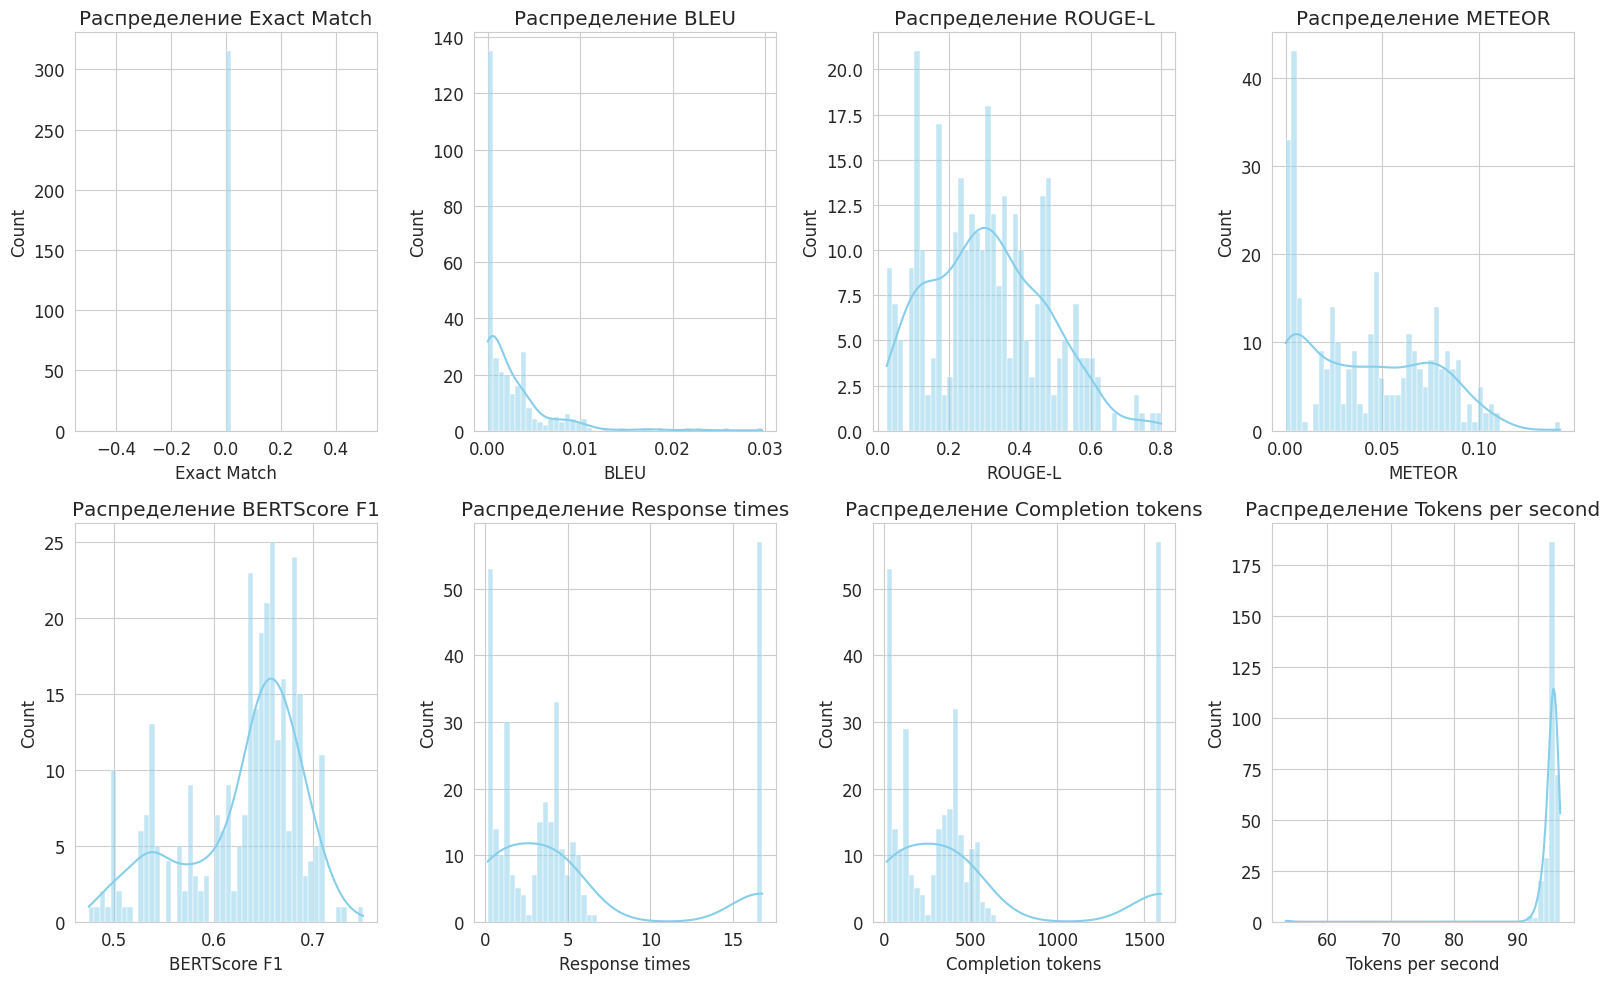

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.histplot(dfs_all[metric], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение {metric}')
    axes[i].set_xlabel(metric)

plt.tight_layout()
plt.show()

In [12]:
# Группировка по имени адаптера
adapter_stats = dfs_all.groupby('Adapter_name')[metrics].agg(['mean', 'median', 'std', 'min', 'max'])
adapter_stats.head()

Exact Match              \
                                                          mean median  std   
Adapter_name                                                                 
VLLM_TEST_with_metrics_clear_model_meta-llama_L...         0.0    0.0  0.0   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...         0.0    0.0  0.0   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...         0.0    0.0  0.0   

                                                                BLEU  \
                                                   min max      mean   
Adapter_name                                                           
VLLM_TEST_with_metrics_clear_model_meta-llama_L...   0   0  0.002646   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...   0   0  0.005090   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...   0   0  0.000169   

                                                                        \
                                                      median       std   
Adapter_name                                                             
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  0.001659  0.003131   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  0.003628  0.005319   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  0.000000  0.000330   

                                                                            \
                                                             min       max   
Adapter_name                                                                 
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  5.978080e-09  0.017104   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  3.263012e-05  0.029708   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  0.000000e+00  0.001066   

                                                    ... Completion tokens  \
                                                    ...              mean   
Adapter_name                                        ...                     
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  ...        288.819048   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  ...        375.971429   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  ...        834.619048   

                                                                             \
                                                    median         std  min   
Adapter_name                                                                  
VLLM_TEST_with_metrics_clear_model_meta-llama_L...   176.0  280.327823   43   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...   394.0  115.573857  112   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  1600.0  791.357018   16   

                                                         Tokens per second  \
                                                     max              mean   
Adapter_name                                                                 
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  1600         95.545742   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...   601         95.791738   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  1600         94.642792   

                                                                         \
                                                       median       std   
Adapter_name                                                              
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  95.646918  0.336677   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  95.833540  0.280714   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  95.417331  4.194652   

                                                                          
                                                          min        max  
Adapter_name                                                              
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  94.318075  96.174472  
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  93.254927  96.310930  
VL

In [13]:
# Добавим также 95-й перцентиль для времени ответа (чтобы оценить долгие хвосты)
percentile_95 = dfs_all.groupby('Adapter_name')['Response times'].quantile(0.95)
adapter_stats[('Response times', 'p95')] = percentile_95

# И долю точных совпадений (Exact Match = 1)
exact_rate = dfs_all.groupby('Adapter_name')['Exact Match'].mean()
adapter_stats[('Exact Match', 'rate')] = exact_rate

adapter_stats.sort_values(('Exact Match', 'rate'), ascending=False).head(10)

Exact Match              \
                                                          mean median  std   
Adapter_name                                                                 
VLLM_TEST_with_metrics_clear_model_meta-llama_L...         0.0    0.0  0.0   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...         0.0    0.0  0.0   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...         0.0    0.0  0.0   

                                                                BLEU  \
                                                   min max      mean   
Adapter_name                                                           
VLLM_TEST_with_metrics_clear_model_meta-llama_L...   0   0  0.002646   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...   0   0  0.005090   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...   0   0  0.000169   

                                                                        \
                                                      median       std   
Adapter_name                                                             
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  0.001659  0.003131   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  0.003628  0.005319   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  0.000000  0.000330   

                                                                            \
                                                             min       max   
Adapter_name                                                                 
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  5.978080e-09  0.017104   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  3.263012e-05  0.029708   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  0.000000e+00  0.001066   

                                                    ... Completion tokens  \
                                                    ...               std   
Adapter_name                                        ...                     
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  ...        280.327823   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  ...        115.573857   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  ...        791.357018   

                                                               \
                                                    min   max   
Adapter_name                                                    
VLLM_TEST_with_metrics_clear_model_meta-llama_L...   43  1600   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  112   601   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...   16  1600   

                                                   Tokens per second  \
                                                                mean   
Adapter_name                                                           
VLLM_TEST_with_metrics_clear_model_meta-llama_L...         95.545742   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...         95.791738   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...         94.642792   

                                                                         \
                                                       median       std   
Adapter_name                                                              
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  95.646918  0.336677   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  95.833540  0.280714   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  95.417331  4.194652   

                                                                          \
                                                          min        max   
Adapter_name                                                               
VLLM_TEST_with_metrics_clear_model_meta-llama_L...  94.318075  96.174472   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...  93.254927  96.310930   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...  53.402939  96.741765   

                                        

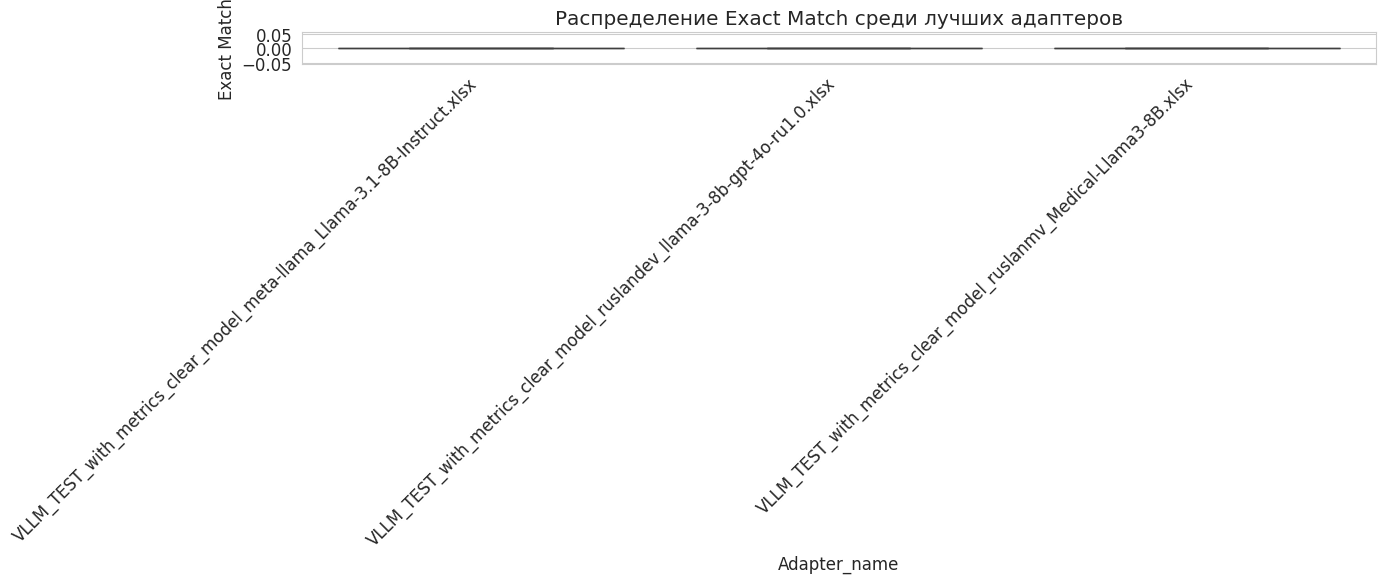

In [14]:
top_adapters = adapter_stats.nlargest(10, ('Exact Match', 'rate')).index
top_data = dfs_all[dfs_all['Adapter_name'].isin(top_adapters)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=top_data, x='Adapter_name', y='Exact Match')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение Exact Match среди лучших адаптеров')
plt.tight_layout()
plt.show()

/tmp/ipykernel_205224/2230009559.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_205224/2230009559.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


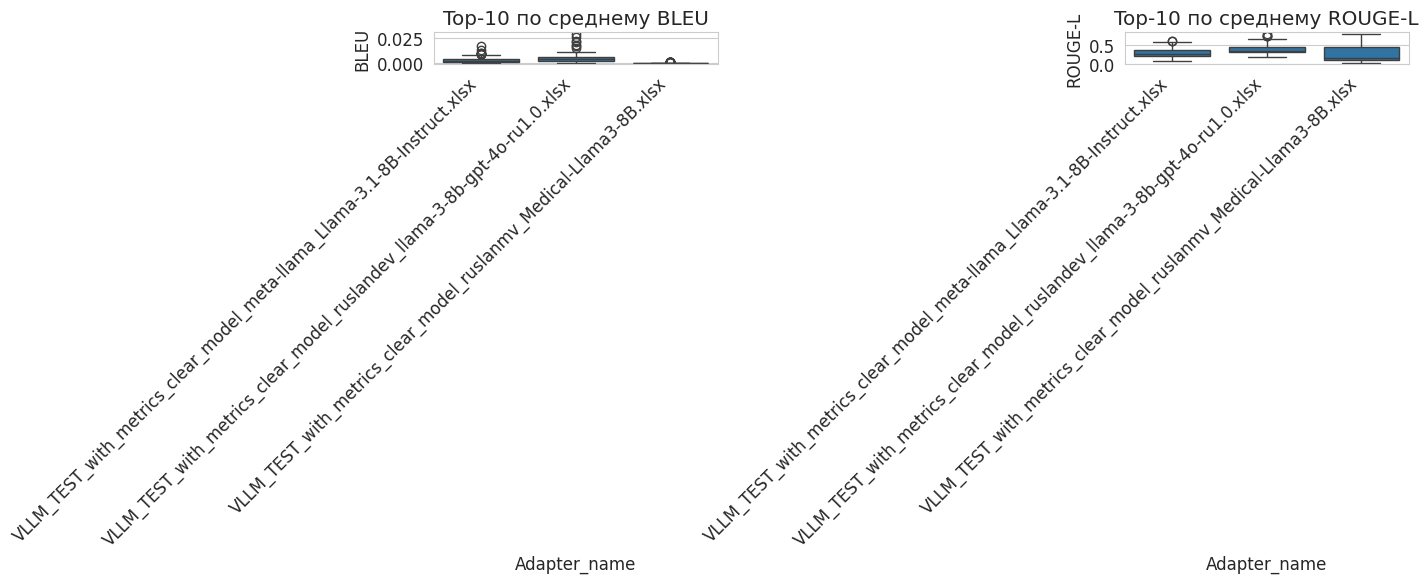

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top-10 по BLEU
top_bleu = adapter_stats.nlargest(10, ('BLEU', 'mean')).index
sns.boxplot(data=dfs_all[dfs_all['Adapter_name'].isin(top_bleu)], x='Adapter_name', y='BLEU', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_title('Top-10 по среднему BLEU')

# Top-10 по ROUGE-L
top_rouge = adapter_stats.nlargest(10, ('ROUGE-L', 'mean')).index
sns.boxplot(data=dfs_all[dfs_all['Adapter_name'].isin(top_rouge)], x='Adapter_name', y='ROUGE-L', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title('Top-10 по среднему ROUGE-L')

plt.tight_layout()
plt.show()

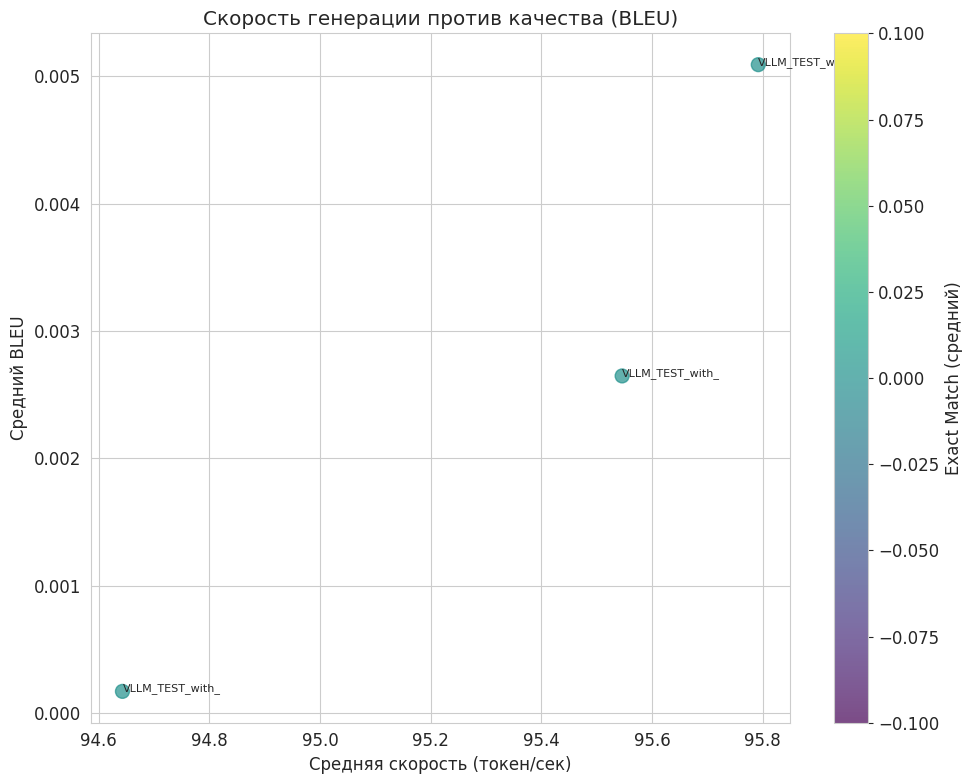

In [16]:
# Сводная таблица средних значений для каждого адаптера
mean_metrics = dfs_all.groupby('Adapter_name')[['BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1', 
                                                 'Exact Match', 'Tokens per second']].mean()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(mean_metrics['Tokens per second'], mean_metrics['BLEU'], 
                      c=mean_metrics['Exact Match'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='Exact Match (средний)')
plt.xlabel('Средняя скорость (токен/сек)')
plt.ylabel('Средний BLEU')
plt.title('Скорость генерации против качества (BLEU)')
for label in mean_metrics.index:
    plt.annotate(label[:15], (mean_metrics.loc[label, 'Tokens per second'], 
                              mean_metrics.loc[label, 'BLEU']), fontsize=8)
plt.tight_layout()
plt.show()

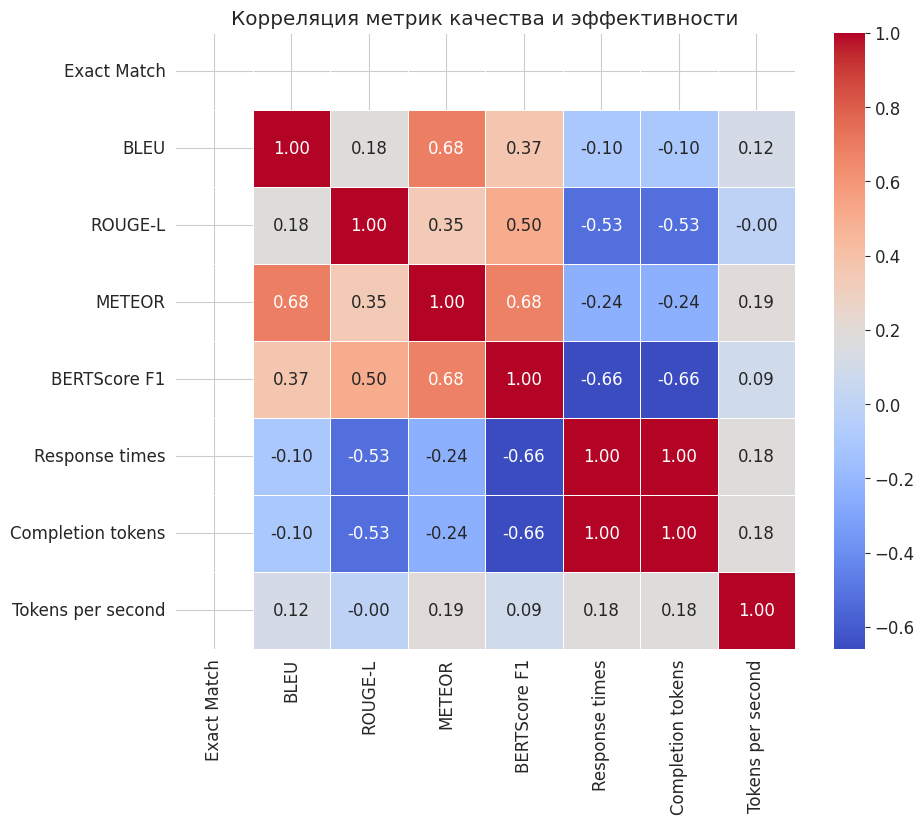

In [17]:
corr = dfs_all[metrics].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция метрик качества и эффективности')
plt.show()

In [18]:
# Нормализуем метрики (min-max) для каждого адаптера
norm_metrics = mean_metrics[['Exact Match', 'BLEU', 'ROUGE-L']].copy()
for col in norm_metrics.columns:
    norm_metrics[col] = (norm_metrics[col] - norm_metrics[col].min()) / (norm_metrics[col].max() - norm_metrics[col].min())

# Интегральный рейтинг (1 = лучший)
norm_metrics['score'] = (0.4 * norm_metrics['Exact Match'] + 
                         0.3 * norm_metrics['BLEU'] + 
                         0.3 * norm_metrics['ROUGE-L'])

# Учитываем стабильность: коэффициент вариации для Exact Match (чем меньше, тем лучше)
cv_exact = dfs_all.groupby('Adapter_name')['Exact Match'].std() / (dfs_all.groupby('Adapter_name')['Exact Match'].mean() + 1e-6)
norm_cv = 1 - (cv_exact - cv_exact.min()) / (cv_exact.max() - cv_exact.min())  # инвертируем

norm_metrics['final_score'] = 0.8 * norm_metrics['score'] + 0.2 * norm_cv

# Сортируем
ranking = norm_metrics.sort_values('final_score', ascending=False)
ranking[['Exact Match', 'BLEU', 'ROUGE-L', 'score', 'final_score']].head(10)

,Exact Match,BLEU,ROUGE-L,score,final_score
Adapter_name,,,,,
VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx,NaN,0.50335,0.331666,NaN,NaN
VLLM_TEST_with_metrics_clear_model_ruslandev_llama-3-8b-gpt-4o-ru1.0.xlsx,NaN,1.00000,1.000000,NaN,NaN
VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx,NaN,0.00000,0.000000,NaN,NaN


In [19]:
# Покажем лучший адаптер и его параметры
best_adapter = ranking.index[0]
print(f"Лучший адаптер: {best_adapter}\n")
print("Его средние метрики:")
mean_metrics.loc[best_adapter]

Лучший адаптер: VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx

Его средние метрики:


BLEU                  0.002646
ROUGE-L               0.289377
METEOR                0.049303
BERTScore F1          0.657155
Exact Match           0.000000
Tokens per second    95.545742
Name: VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx, dtype: float64

In [20]:
# Сравним лучшего с худшим по Exact Match
worst_adapter = ranking.index[-1]
print(f"Худший адаптер (по интегральной оценке): {worst_adapter}\n")
print("Средние метрики худшего:")
mean_metrics.loc[worst_adapter]

Худший адаптер (по интегральной оценке): VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx

Средние метрики худшего:


BLEU                  0.000169
ROUGE-L               0.236925
METEOR                0.005457
BERTScore F1          0.562275
Exact Match           0.000000
Tokens per second    94.642792
Name: VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx, dtype: float64

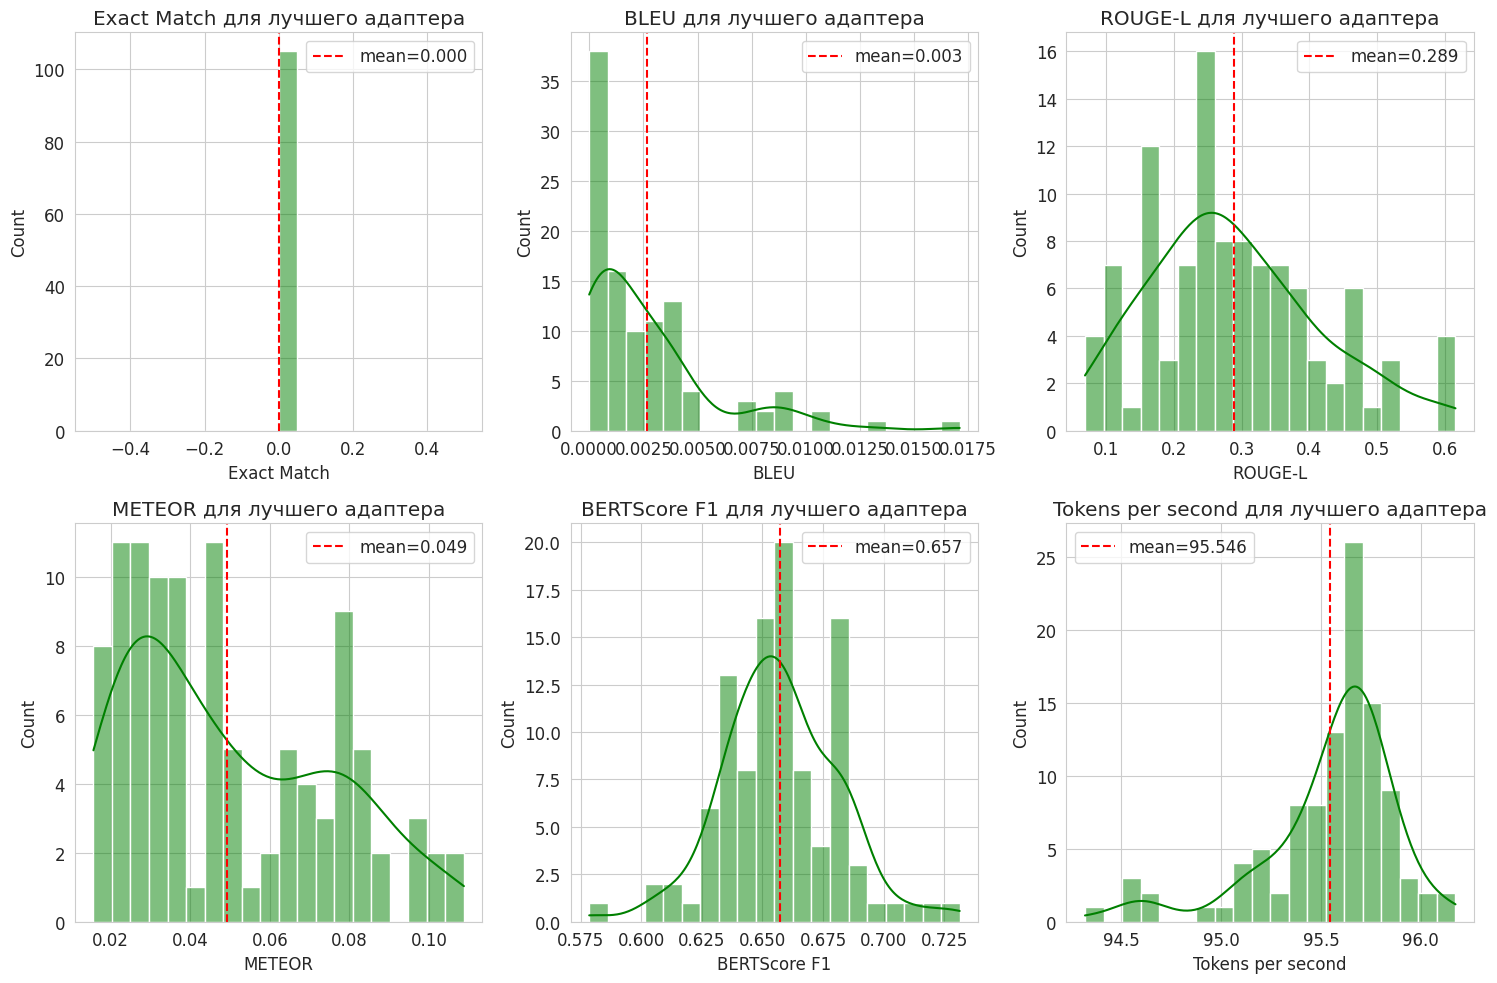

In [21]:
best_data = dfs_all[dfs_all['Adapter_name'] == best_adapter]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1', 'Tokens per second']
for i, metric in enumerate(plot_metrics):
    sns.histplot(best_data[metric], bins=20, kde=True, ax=axes[i], color='green')
    axes[i].set_title(f'{metric} для лучшего адаптера')
    axes[i].axvline(best_data[metric].mean(), color='red', linestyle='--', label=f'mean={best_data[metric].mean():.3f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [22]:
best_adapter

'VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct.xlsx'

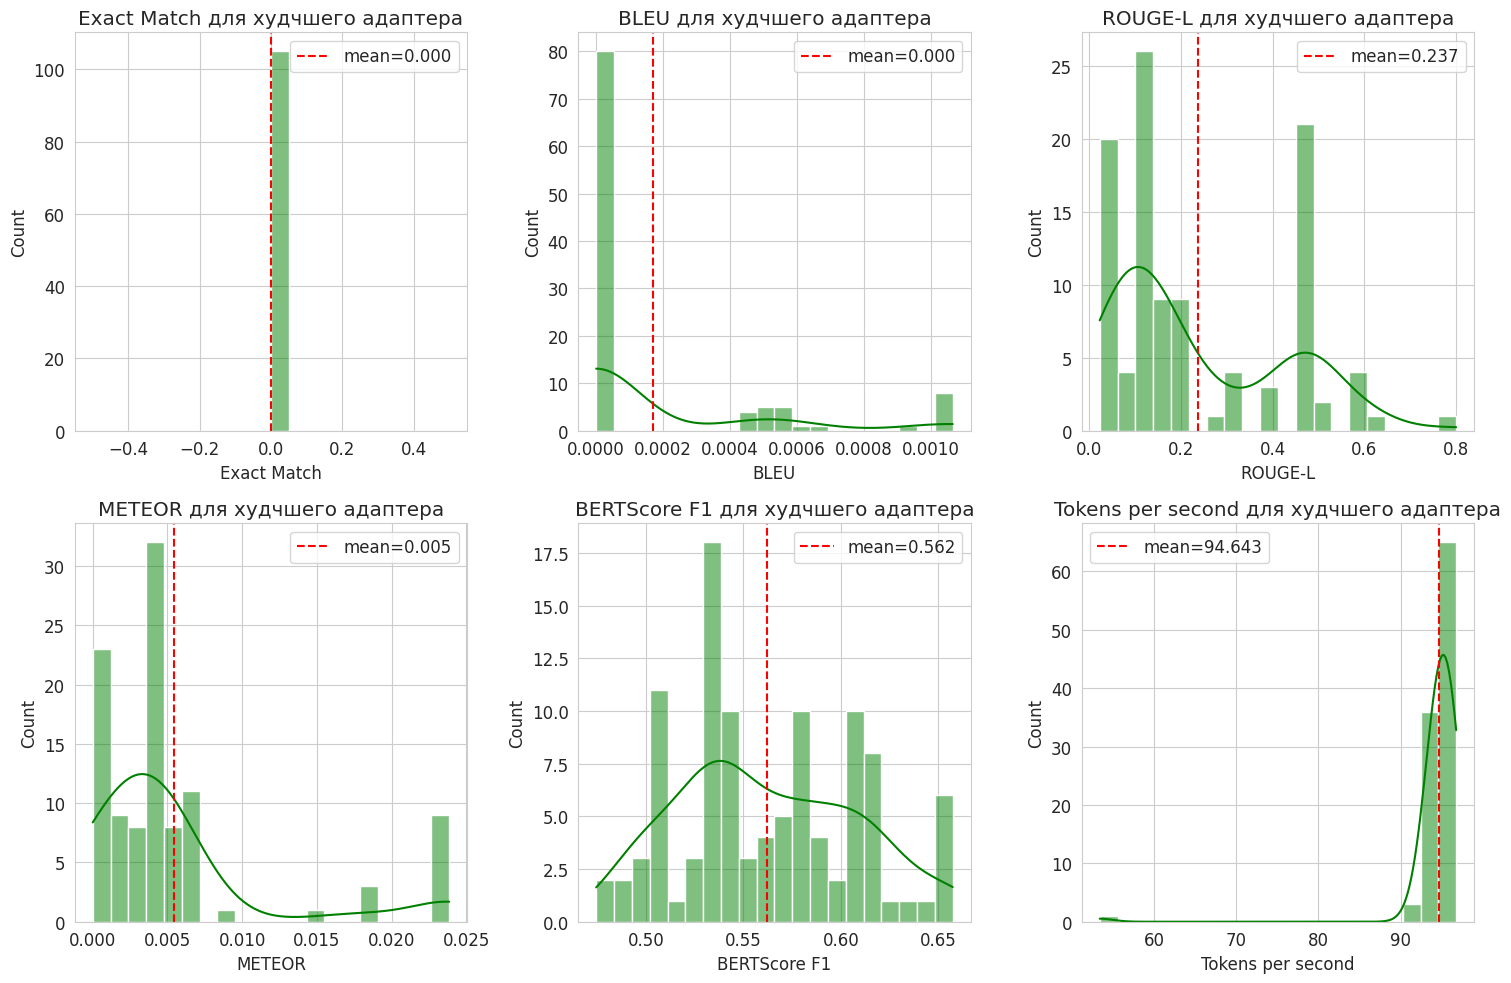

In [23]:
worst_data = dfs_all[dfs_all['Adapter_name'] == worst_adapter]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1', 'Tokens per second']
for i, metric in enumerate(plot_metrics):
    sns.histplot(worst_data[metric], bins=20, kde=True, ax=axes[i], color='green')
    axes[i].set_title(f'{metric} для худчшего адаптера')
    axes[i].axvline(worst_data[metric].mean(), color='red', linestyle='--', label=f'mean={worst_data[metric].mean():.3f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [24]:
worst_adapter

'VLLM_TEST_with_metrics_clear_model_ruslanmv_Medical-Llama3-8B.xlsx'

In [25]:
# Выводы по лучшему адаптеру
print("Оценка лучшего адаптера:")
print(f"- Exact Match достигается в {best_data['Exact Match'].mean()*100:.1f}% случаев")
print(f"- Средний BLEU: {best_data['BLEU'].mean():.3f}")
print(f"- Средний ROUGE-L: {best_data['ROUGE-L'].mean():.3f}")
print(f"- Медианное время ответа: {best_data['Response times'].median():.2f} сек")
print(f"- Скорость генерации: {best_data['Tokens per second'].mean():.1f} токен/сек")
print(f"- Стабильность (ст.откл. Exact Match): {best_data['Exact Match'].std():.3f}")

Оценка лучшего адаптера:
- Exact Match достигается в 0.0% случаев
- Средний BLEU: 0.003
- Средний ROUGE-L: 0.289
- Медианное время ответа: 1.84 сек
- Скорость генерации: 95.5 токен/сек
- Стабильность (ст.откл. Exact Match): 0.000


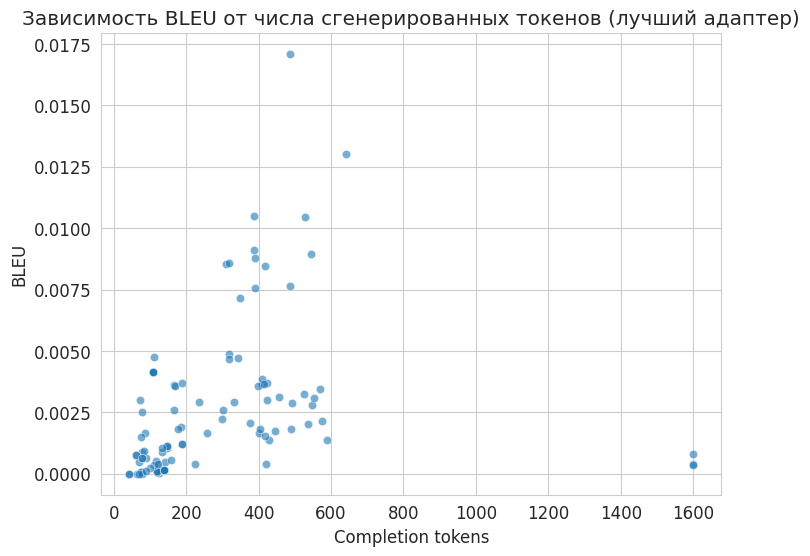

In [26]:
# Анализ: корреляция длины ответа с качеством для лучшего адаптера
plt.figure(figsize=(8, 6))
sns.scatterplot(data=best_data, x='Completion tokens', y='BLEU', alpha=0.6)
plt.title('Зависимость BLEU от числа сгенерированных токенов (лучший адаптер)')
plt.xlabel('Completion tokens')
plt.ylabel('BLEU')
plt.show()